In [ ]:
import os
import pandas as pd

data = []
path = "bbc" 

for category in os.listdir(path):
    category_path = os.path.join(path, category)
    if not os.path.isdir(category_path):
        continue
    for file in os.listdir(category_path):
        file_path = os.path.join(category_path, file)
        if file.endswith(".txt"):
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()
                data.append({"category": category, "text": text})
df = pd.DataFrame(data)

Số lượng báo

In [30]:
print("Total samples:", len(df))
label_counts = df['category'].value_counts()
print(label_counts)

Total samples: 2225
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [31]:
# percent of imbalance
print(label_counts / len(df) * 100)

category
sport            22.966292
business         22.921348
politics         18.741573
tech             18.022472
entertainment    17.348315
Name: count, dtype: float64


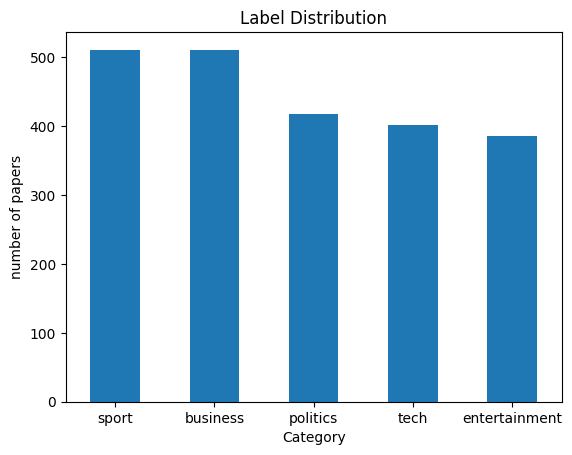

In [32]:
import matplotlib.pyplot as plt
label_counts.plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Category")
plt.ylabel("number of papers")
plt.xticks(rotation=360) 
plt.show()

Tổng quan dữ liệu: 
- Kích thuớc: 2225 văn bản, phân loại vào 5 chủ đề
- Độ cân bằng: Tương đối cân bằng:
    + Nhóm Sport & business dẫn đầu, vào khoảng 23%
    + Nhóm Entertainment chiếm tỉ trọng thấp nhất nhưng cũng rơi vào khoảng 17.3%
=> Khoảng gap không quá lớn trên từng loại dữ liệu, chênh lệch tối đa khoảng 6%

In [33]:
# số lượng từ mỗi bài
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print(df['word_count'].describe())

count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64


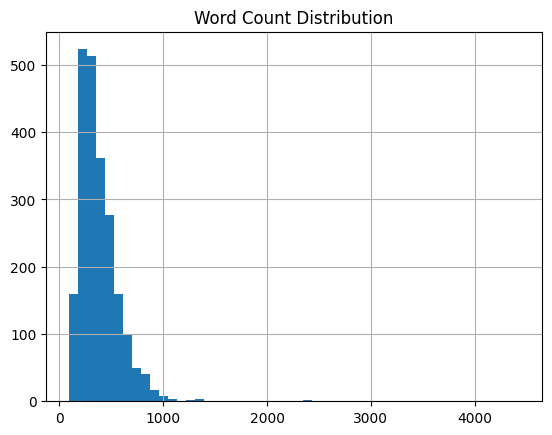

In [34]:
df['word_count'].hist(bins=50)
plt.title("Word Count Distribution")
plt.show()

- Trung bình mỗi bài viết dài khoảng 384 từ. Tuy nhiên, độ lệch chuẩn rất lớn (238 từ) cho thấy sự dao động mạnh về dung lượng giữa các bài.  
- Phân phối độ lệch: Phân phối dữ liệu bị lệch phải rõ rệt. Phần lớn dữ liệu tập trung ở vùng 100 - 600 từ, nhưng xuất hiện các giá trị ngoại lệ cực lớn, với bài viết dài nhất lên tới 4432 từ.  
- Tuy nhiên dữ liệu thô khá sạch, khi bài viết ngắn nhất có 89 từ, biểu thị rõ không có file rỗng hoặc chỉ chứa tiêu đề.
=> Cần huớng xử lý ngoại lệ, nên thiết lập độ dài tối đa ở mức khoảng 800 từ khi chuẩn hóa dữ liệu đầu vào, giúp tối ưu hóa việc làm

In [35]:
#word count by category
print(df.groupby('category')['word_count'].mean())

category
business         328.880392
entertainment    330.621762
politics         453.973621
sport            329.262231
tech             502.695761
Name: word_count, dtype: float64


- Nhóm nội dung chuyên sâu: Các bài viết thuộc chủ đề tech và politics có dung lượng lớn nhất, đạt trung bình lần lượt là 502 từ và 453 từ mỗi bài.  
- Nhóm nội dung tiêu chuẩn: Các chủ đề business, sport, và entertainment có độ dài trung bình gần như tương đương nhau.